In [ ]:
import numpy as np
import pandas as pd
import os
import math
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


tensorflow import for keras and layers

In [ ]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


data set

In [ ]:
df = pd.read_csv('/content/Churn_Modelling.csv')

In [ ]:
print("Data shape:", df.shape)
print("Columns:", list(df.columns))
print(df.head())

Data shape: (10000, 14)
Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2 

Target (y) → whether the customer exited (1) or not (0)
Features (X) → all other columns

In [ ]:
TARGET_COL = 'Exited'
y = df[TARGET_COL].values
X = df.drop(columns=[TARGET_COL])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

# Detects numeric vs categorical columns automatically

try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)


# Creates a One-Hot Encoder for categorical variables.

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', ohe, categorical_cols),
    ],
    remainder='drop'
)

X_train_p = preprocessor.fit_transform(X_train)
X_test_p  = preprocessor.transform(X_test)

input_dim = X_train_p.shape[1]
print(f"Transformed feature dimension: {input_dim}")


Transformed feature dimension: 2635


Build the Neural Network

In [ ]:
num_classes = len(np.unique(y_train))
assert num_classes == 2, f"Expected 2 classes; got {num_classes}"

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])


BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 20

optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_train_p, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    shuffle=True
)

test_loss, test_acc = model.evaluate(X_test_p, y_test, verbose=0)
print(f"\nTest Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

y_proba = model.predict(X_test_p, verbose=0)
y_pred = y_proba.argmax(axis=1)

auc_bin = roc_auc_score(y_test, y_proba[:, 1])
print(f"Test ROC-AUC (class 1): {auc_bin:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 128)            │       337,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 348,306 (1.33 MB)

 Trainable params: 348,306 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7779 - loss: 0.4951 - val_accuracy: 0.8644 - val_loss: 0.3578
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8605 - loss: 0.3432 - val_accuracy: 0.8594 - val_loss: 0.3616
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8945 - loss: 0.2590 - val_accuracy: 0.8269 - val_loss: 0.4572
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9396 - loss: 0.1595 - val_accuracy: 0.8112 - val_loss: 0.6279
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9691 - loss: 0.0876 - val_accuracy: 0.7950 - val_loss: 0.7589
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9804 - loss: 0.0504 - val_accuracy: 0.7887 - val_loss: 0.8788
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9881 - loss: 0.0350 - val_accuracy: 0.7450 - val_loss: 1.1224
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9881 - loss: 0.0346 - val_accur

Data shape: (10000, 14)
Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2 

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │       337,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 348,306 (1.33 MB)

 Trainable params: 348,306 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7731 - loss: 0.5166 - val_accuracy: 0.8569 - val_loss: 0.3740
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8611 - loss: 0.3500 - val_accuracy: 0.8556 - val_loss: 0.3631
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8970 - loss: 0.2646 - val_accuracy: 0.8156 - val_loss: 0.4555
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9344 - loss: 0.1691 - val_accuracy: 0.8081 - val_loss: 0.5875
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9607 - loss: 0.1009 - val_accuracy: 0.8263 - val_loss: 0.7177
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9758 - loss: 0.0660 - val_accuracy: 0.8000 - val_loss: 0.7818
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9784 - loss: 0.0534 - val_accuracy: 0.7487 - val_loss: 1.0506
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9866 - loss: 0.0377 - val_accuracy: 

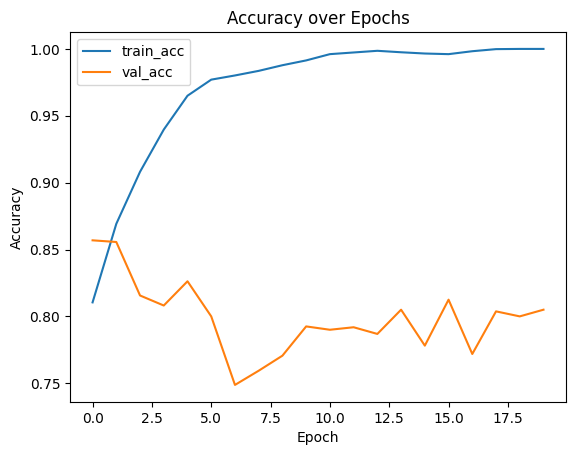

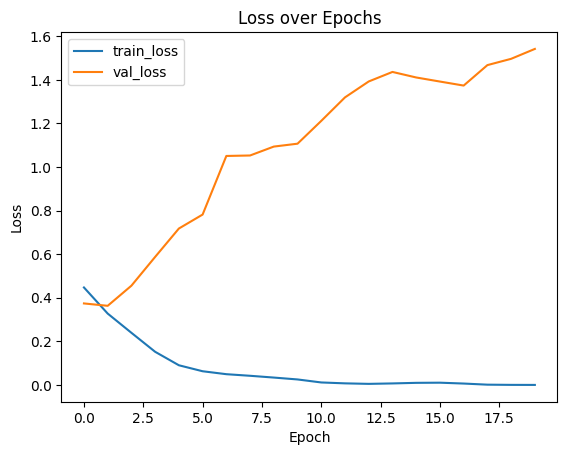


Saved files:
 - churn_nn_softmax.h5
 - preprocessor_ohe_scaler.pkl


In [ ]:



plt.figure()
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

model.save('churn_nn_softmax.h5')

import joblib
joblib.dump(preprocessor, 'preprocessor_ohe_scaler.pkl')

print("\nSaved files:")
print(" - churn_nn_softmax.h5")
print(" - preprocessor_ohe_scaler.pkl")

confusion matrix


Test Loss: 1.4645 | Test Acc: 0.8010
Test ROC-AUC (class 1): 0.7647

Classification Report:
              precision    recall  f1-score   support

           0     0.8637    0.8908    0.8770      1593
           1     0.5126    0.4496    0.4791       407

    accuracy                         0.8010      2000
   macro avg     0.6881    0.6702    0.6780      2000
weighted avg     0.7922    0.8010    0.7960      2000

Confusion Matrix:
[[1419  174]
 [ 224  183]]


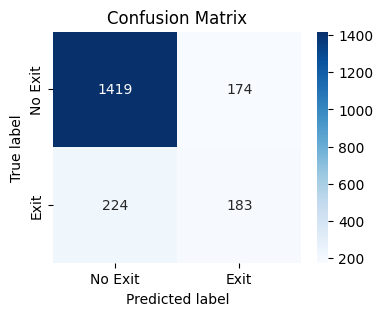

In [ ]:

test_loss, test_acc = model.evaluate(X_test_p, y_test, verbose=0)
print(f"\nTest Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")


y_proba = model.predict(X_test_p, verbose=0)
y_pred = y_proba.argmax(axis=1)

auc_bin = roc_auc_score(y_test, y_proba[:, 1])
print(f"Test ROC-AUC (class 1): {auc_bin:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)


import seaborn as sns
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Exit','Exit'],
            yticklabels=['No Exit','Exit'])
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix')
plt.show()


# Task
Implement a Convolutional Neural Network (CNN) for a neural network task. The implementation should include data preprocessing suitable for a CNN, the implementation of the CNN algorithm itself, and a comprehensive evaluation of the model. The evaluation should include code for calculating accuracy, precision, recall, F1 score, and generating a confusion matrix. Additionally, select and use an appropriate cost function from options like RMSE, MAE, or Categorical Cross-entropy, considering the nature of the problem.

## Understand the data

### Subtask:
Analyze the dataset to determine if a CNN is suitable for the features.


**Reasoning**:
Analyze the features in the dataset to determine if they have spatial or temporal relationships suitable for a CNN. The features are a mix of numerical and categorical data representing customer attributes and behavior at a single point in time.



In [ ]:
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)